In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from config import RAW_DATA, PROCESSED_DATA # pyright: ignore[reportMissingImports]
import src.plots as plots # pyright: ignore[reportMissingImports]

In [2]:
df = pd.read_csv(RAW_DATA / 'Online Retail.csv',
                 dtype={'CustomerID': 'object'}
                 )

In [3]:
# Display a random sample of 5 rows from the DataFrame
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
275810,561020,23335,EGG FRYING PAN IVORY,1,7/22/11 17:21,2.08,13563,United Kingdom
395911,571046,21034,REX CASH+CARRY JUMBO SHOPPER,2,10/13/11 13:35,0.95,18096,United Kingdom
428553,573485,82482,WOODEN PICTURE FRAME WHITE FINISH,4,10/31/11 11:37,2.95,15752,United Kingdom
537624,581334,22384,LUNCH BAG PINK POLKADOT,2,12/8/11 12:07,1.65,17841,United Kingdom
25183,538354,21733,RED HANGING HEART T-LIGHT HOLDER,12,12/10/10 15:45,2.95,16873,United Kingdom


In [4]:
# Summary information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [5]:
# Number of unique values in key columns
print("Unique invoice numbers: ", df['InvoiceNo'].nunique())
print("Unique products: ", df['StockCode'].nunique())
print("Unique customers: ", df['CustomerID'].nunique())
print("Unique countries: ", df['Country'].nunique())

Unique invoice numbers:  25900
Unique products:  4070
Unique customers:  4372
Unique countries:  38


In [6]:
# Change invoice date to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%m/%d/%y %H:%M')

# Get time range
min_date = df["InvoiceDate"].min()
max_date = df["InvoiceDate"].max()
date_range = max_date - min_date

print("Earliest date: ", min_date)
print("Latest date: ", max_date)
print("Date range: ", date_range)

Earliest date:  2010-12-01 08:26:00
Latest date:  2011-12-09 12:50:00
Date range:  373 days 04:24:00


In [7]:
# Filter out rows with non-positive quantity (returns, cancellations, errors)
df = df[df["Quantity"] > 0]

# Filter out rows with non-positive unit price (free items, accounting adjustments, errors)
df = df[df["UnitPrice"] > 0]

In [8]:
# Calculate revenue column
df['Revenue'] = round(df['Quantity'] * df['UnitPrice'], 2)

In [9]:
# Calculate total revenue per product
product_sales = (
    df.groupby("StockCode")["Revenue"].sum().sort_values(ascending=False).reset_index()
)

Not all products matter equally. That's why I'm identifying the top 20% of products which contribute to 80% of total revenue.

In [10]:
# Identify the top 20% of products that contribute to 80% of total revenue
pareto_products = int(len(product_sales) * 0.20)
pareto_products_list = product_sales["StockCode"].head(pareto_products).tolist()

# Filter the original DataFrame to include only the Pareto products
df_pareto = df[df["StockCode"].isin(pareto_products_list)].copy()

# Calculate the total revenue from Pareto products and overall total revenue
pareto_revenue = round(df_pareto["Revenue"].sum(), 2)
total_revenue = round(df['Revenue'].sum(), 2)
pareto_percentage = pareto_revenue / total_revenue

# Calculate the cumulative revenue and cumulative percentage for the Pareto products
product_sales["cum_revenue"] = product_sales["Revenue"].cumsum()
product_sales["cum_pct"] = product_sales["cum_revenue"] / total_revenue

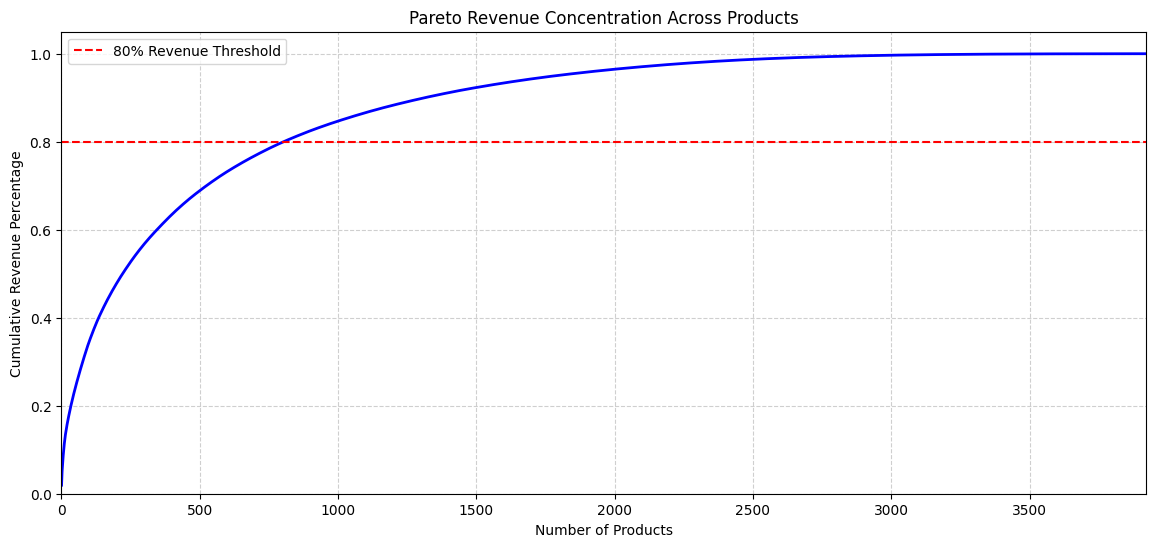

Metric                                   | Value              | Breakdown / Context
------------------------------------------------------------------------------------------
Top 20% Products (Count)                 | 784                | The core revenue drivers of the inventory.
Total Product Catalog                    | 3922               | Total SKUs analyzed.
Pareto Products Revenue                  | $8,474,430.60      | Cash flow generated only by the top 20% items.
Total Store Revenue                      | $10,666,684.54     | Gross revenue across all items.
Pareto Revenue Share (%)                 | 79.45%             | The Headline: The business share carried by the top 20%.
------------------------------------------------------------------------------------------


In [11]:
# Visualize the cumulative revenue percentage to show the Pareto distribution
plots.plot_pareto_sales(product_sales)

print(f"{'Metric':<40} | {'Value':<18} | {'Breakdown / Context'}")
print("-" * 90)
print(f"{'Top 20% Products (Count)':<40} | {pareto_products:<18} | The core revenue drivers of the inventory.")
print(f"{'Total Product Catalog':<40} | {len(product_sales):<18} | Total SKUs analyzed.")
print(f"{'Pareto Products Revenue':<40} | ${pareto_revenue:<17,.2f} | Cash flow generated only by the top 20% items.")
print(f"{'Total Store Revenue':<40} | ${total_revenue:<17,.2f} | Gross revenue across all items.")
print(f"{'Pareto Revenue Share (%)':<40} | {pareto_percentage:<18.2%} | The Headline: The business share carried by the top 20%.")
print("-" * 90)

In [12]:
# Calculate weekly sales for each product
weekly_product_sales = (
    df.groupby(["StockCode", pd.Grouper(key="InvoiceDate", freq="W-MON")])
    .agg({"Quantity": "sum", "Revenue": "sum"})
    .reset_index()
)

# Calculate weekly sales for Pareto products
weekly_pareto_product_sales = (
    df_pareto.groupby(["StockCode", pd.Grouper(key="InvoiceDate", freq="W-MON")])
    .agg({"Quantity": "sum", "Revenue": "sum"})
    .reset_index()
)

High-value does not always mean forecastable.

Some top products appear sporadically, have missing observations or insufficient continuity for lag features.

I am narrowing it down to top products with at least 53 weeks of data.

In [13]:
# Identify products with at least 53 weeks of data (1 year of weekly data)
weekly_count = weekly_pareto_product_sales["StockCode"].value_counts()
fully_observed_products_list = weekly_count[weekly_count >= 53].index.tolist()
fully_observed_products = df[df["StockCode"].isin(fully_observed_products_list)]

# Filter to only eligible products
weekly_fully_observed_product_sales = (
    fully_observed_products.groupby(["StockCode", pd.Grouper(key="InvoiceDate", freq="W-MON")])
    .agg({"Quantity": "sum", "Revenue": "sum"})
    .reset_index()
)

In [14]:
print(f"Total products with at least 1 year of data: {len(fully_observed_products_list)}")

Total products with at least 1 year of data: 232


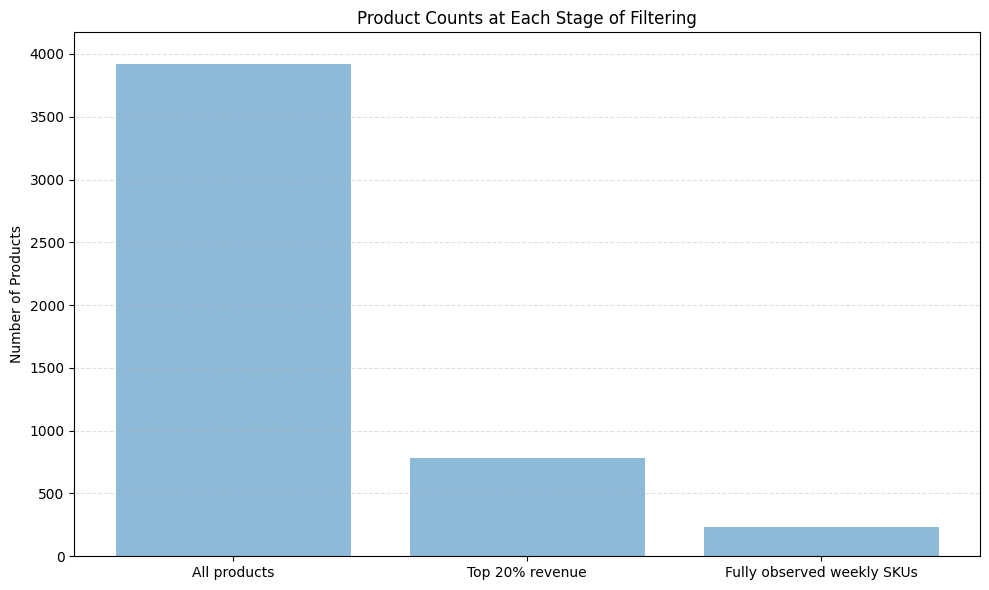

In [15]:
products = [
    "All products",
    "Top 20% revenue",
    "Fully observed weekly SKUs"]

count = [
    len(product_sales),
    len(pareto_products_list),
    len(fully_observed_products_list)
    ]

plt.figure(figsize=(10, 6))

bars = plt.bar(products, count, alpha=0.5)
plt.title("Product Counts at Each Stage of Filtering")
plt.ylabel("Number of Products")
plt.ylim(0, max(count) + 250)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [16]:
# Aggregate weekly sales to get total revenue per week
total_weekly_sales = weekly_product_sales.groupby("InvoiceDate")["Revenue"].sum().reset_index()

# Aggregate weekly sales to get total revenue per week for Pareto products
total_weekly_pareto_sales = weekly_pareto_product_sales.groupby("InvoiceDate")["Revenue"].sum().reset_index()

# Aggregate weekly sales to get total revenue per week for fully observed products
total_weekly_fully_observed_sales = weekly_fully_observed_product_sales.groupby("InvoiceDate")["Revenue"].sum().reset_index()

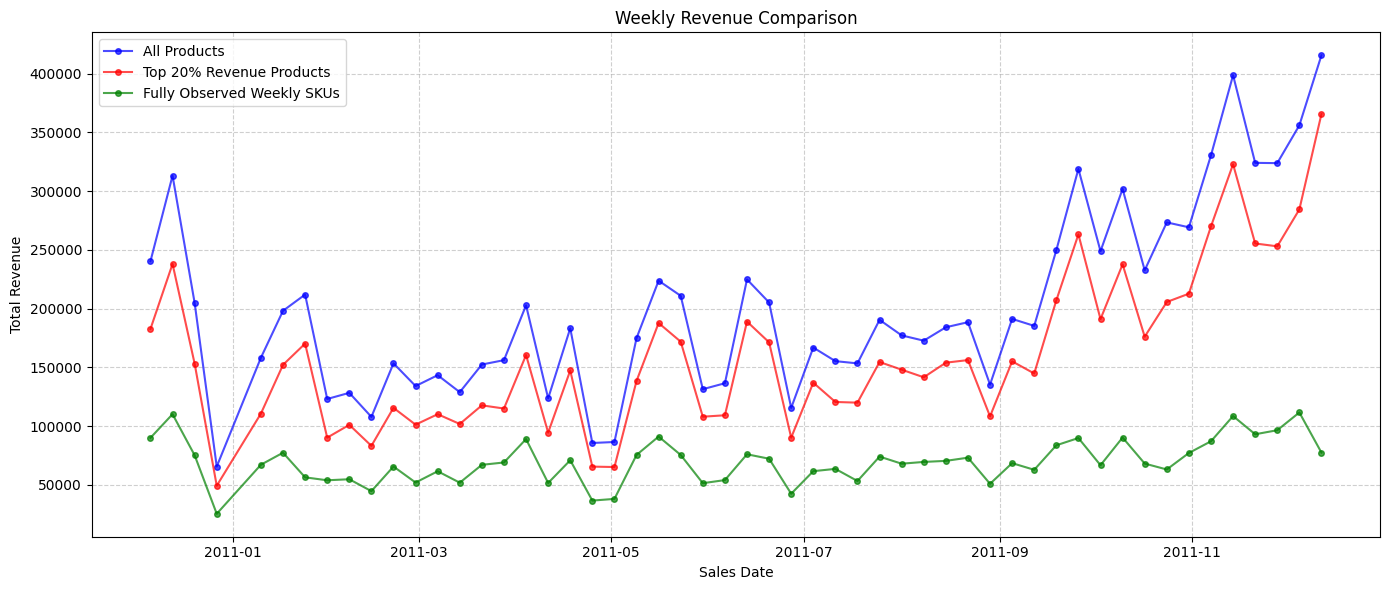

In [17]:
plots.plot_weekly_sales_comparison(
    (total_weekly_sales, "All Products"),
    (total_weekly_pareto_sales, "Top 20% Revenue Products"),
    (total_weekly_fully_observed_sales, "Fully Observed Weekly SKUs")
)

Although continuity filtering reduced the modeling universe from 784 to 232 SKUs, the retained products preserved broader weekly revenue dynamics, indicating that statistical filtering did not materially distort underlying commercial demand patterns.

In [18]:
# Calculate coefficient of variation (CV) for weekly sales quantity for each SKU in the fully observed products dataset
sku_cv = (
    weekly_fully_observed_product_sales
    .groupby("StockCode")["Quantity"]
    .agg(
        mean_qty="mean",
        std_qty="std"
    )
)

sku_cv["cv"] = (
    sku_cv["std_qty"] /
    sku_cv["mean_qty"]
)

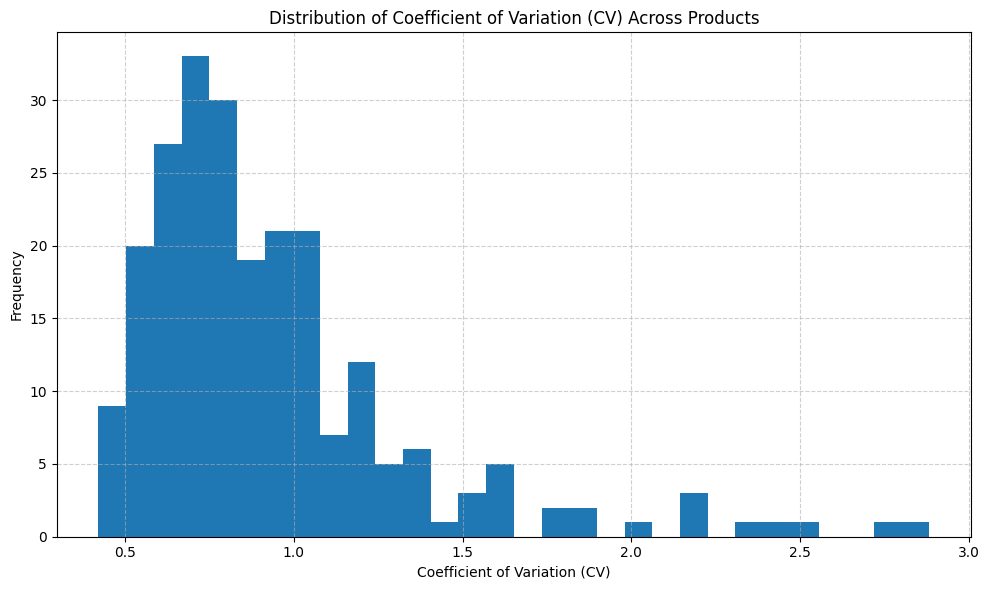

count    232.000000
mean       0.934933
std        0.414047
min        0.420893
25%        0.674919
50%        0.819343
75%        1.058227
max        2.883117
Name: cv, dtype: float64

In [19]:
# Visualize distribution of CV across products
plt.figure(figsize=(10, 6))

sku_cv["cv"].hist(bins=30)

plt.title("Distribution of Coefficient of Variation (CV) Across Products")
plt.xlabel("Coefficient of Variation (CV)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

sku_cv["cv"].describe()

The Coefficient of Variation (CoV) is used in supply chain management to measure demand volatility and forecastability for individual SKUs.

Median CV = 0.82 means high weekly volatility (weekly demand standard deviation is about 82% of its average demand.)

75th percentile = 1.06 (at least 25% of products are extremely volatile.)

Max = 2.88 (some products are very unstable.)

Conclusion: Initial Pareto analysis identified 784 products responsible for approximately 80% of total revenue. However, weekly forecasting requires uninterrupted historical observations to support lag-based feature engineering. Applying continuity constraints reduced the modeling universe to 232 fully observed products. Despite this reduction, the retained subset preserved broader catalog revenue dynamics while maintaining realistic demand volatility, providing a statistically reliable and commercially meaningful forecasting target.

In [20]:
# Save the fully observed products weekly sales data for feature_engineering and modeling
weekly_fully_observed_product_sales.to_parquet(PROCESSED_DATA / 'weekly_fully_observed_product_sales.parquet', index=False)